# Proyecto Final Econometría II

In [5]:
#librerias a importar
import io, re
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
#from google.colab import files
import numpy as np
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox




In [6]:
# leer el archivo
raw = pd.read_excel(r'C:\Users\narro\OneDrive - Fundacion Universidad de las Americas Puebla\semestre 9\econometria II\ecoII\trabajo de clase\proyectofinal\tasa_participacion_mujeres.xls', header=None)

En esta seccion se realiza un pequeño preprocesamiento de los datos apra tener un DF de pandas para trabajar. 

In [7]:
# Detectar fila de inicio
date_mask = raw[0].astype(str).str.match(r"^\d{4}/\d{2}$", na=False)
if not date_mask.any():
    #Si la fecha viene como datetime ya; intentamos detectar filas convertibles a periodo
    tmp = pd.to_datetime(raw[0], errors="coerce", format="%Y/%m")
    date_mask = tmp.notna()

if not date_mask.any():
    # Sino, buscar AAAA-MM
    date_mask = raw[0].astype(str).str.match(r"^\d{4}[-]\d{2}$", na=False)

assert date_mask.any(), "No se encontró una fila con fechas tipo '2005/01' o '2005-01' en la primera columna."
start_row = int(date_mask[date_mask].index[0])

# Construir DataFrame limpio (Periodos en col 0 y Valor en col 1)
df = raw.loc[start_row:, [0, 1]].copy()
df.columns = ["Fecha", "Tasa_participacion"]

# Tipos correctos
df["Fecha"] = pd.to_datetime(df["Fecha"].astype(str), format="%Y/%m", errors="coerce")
if df["Fecha"].isna().all():
    df["Fecha"] = pd.to_datetime(df["Fecha"].astype(str), format="%Y-%m", errors="coerce")

df["Tasa_participacion"] = pd.to_numeric(df["Tasa_participacion"], errors="coerce")

In [8]:
df

,Fecha,Tasa_participacion
4,2005-01-01,40.351692
5,2005-02-01,40.432370
6,2005-03-01,41.179709
7,2005-04-01,39.732705
8,2005-05-01,41.027773
...,...,...
253,NaT,NaN
254,NaT,NaN
255,NaT,NaN
256,NaT,NaN


In [9]:

# Limpiar y ordenar
df = (df
      .dropna(subset=["Fecha", "Tasa_participacion"])
      .set_index("Fecha")
      .sort_index())


Comienza la exploración de los datos.

In [10]:


# Reporte en consola
ini, fin = df.index.min(), df.index.max()
print(f"Periodo detectado: {ini.strftime('%Y-%m')} a {fin.strftime('%Y-%m')}")
print("\nResumen estadístico:")
print(df["Tasa_participacion"].describe().to_string())

# Guardar versión limpia
clean_name = "tasa_participacion_mujeres_clean.csv"
df.to_csv(clean_name, encoding="utf-8")
print(f"\nArchivo limpio guardado como: {clean_name}")


Periodo detectado: 2005-01 a 2025-09

Resumen estadístico:
count    249.000000
mean      43.472531
std        1.748154
min       34.616667
25%       42.457499
50%       43.366709
75%       44.539689
max       47.135221

Archivo limpio guardado como: tasa_participacion_mujeres_clean.csv


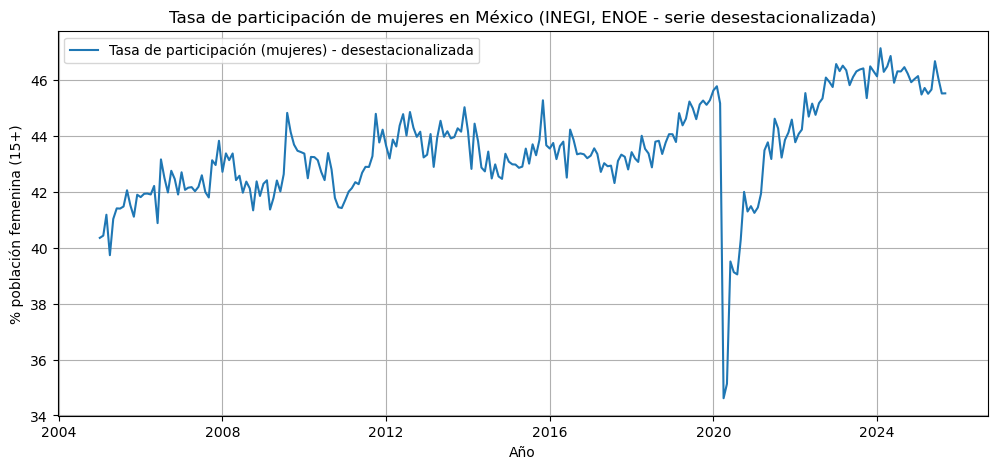

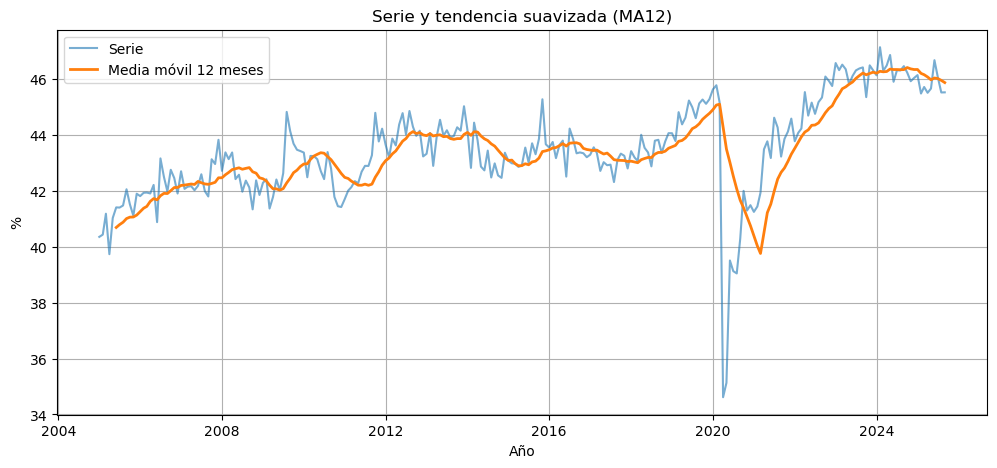

In [11]:

# Gráficas
plt.figure(figsize=(12,5))
plt.plot(df["Tasa_participacion"], label="Tasa de participación (mujeres) - desestacionalizada")
plt.title("Tasa de participación de mujeres en México (INEGI, ENOE - serie desestacionalizada)")
plt.xlabel("Año")
plt.ylabel("% población femenina (15+)")
plt.grid(True)
plt.legend()
plt.show()

#  Tendencia suavizada con media móvil de 12 meses
df["MA12"] = df["Tasa_participacion"].rolling(window=12, min_periods=6).mean()
plt.figure(figsize=(12,5))
plt.plot(df["Tasa_participacion"], label="Serie", alpha=0.6)
plt.plot(df["MA12"], label="Media móvil 12 meses", linewidth=2)
plt.title("Serie y tendencia suavizada (MA12)")
plt.xlabel("Año")
plt.ylabel("%")
plt.grid(True)
plt.legend()
plt.show()


#  Exploración y Transformaciones

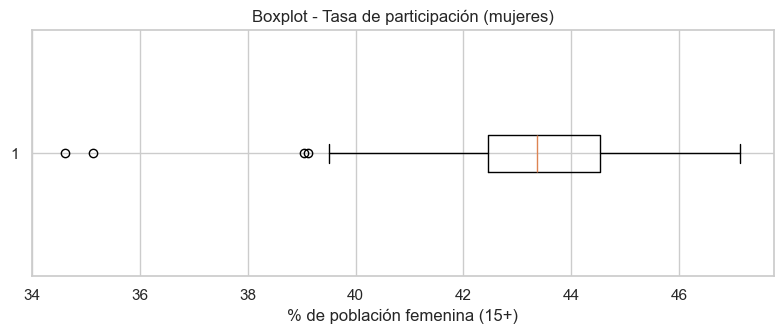

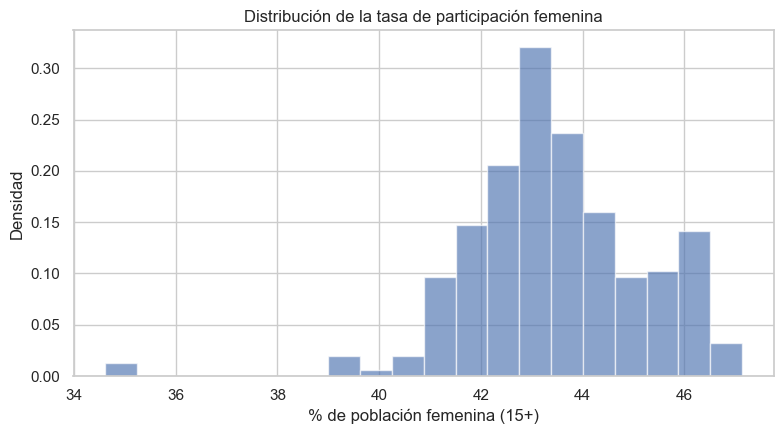

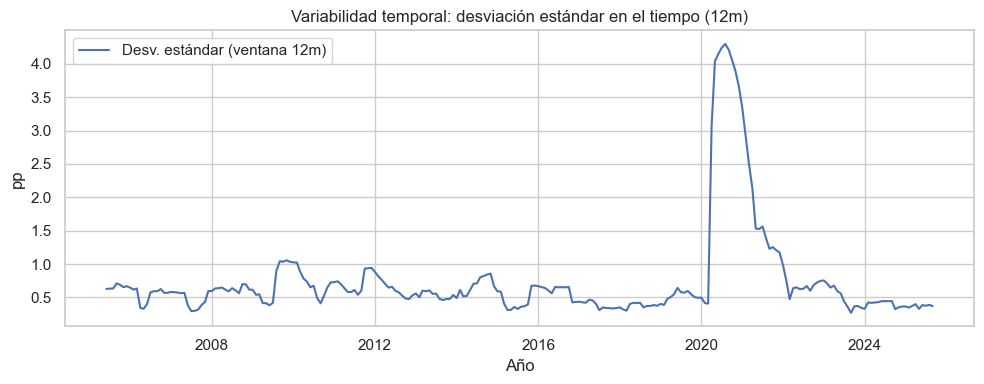

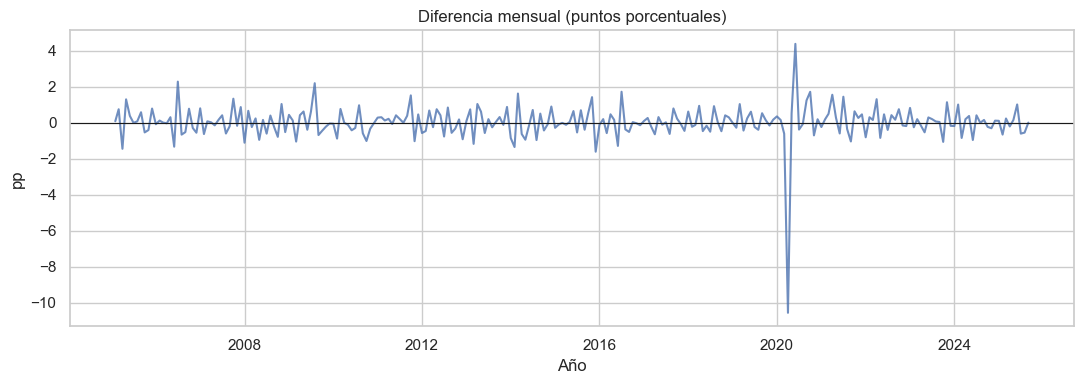

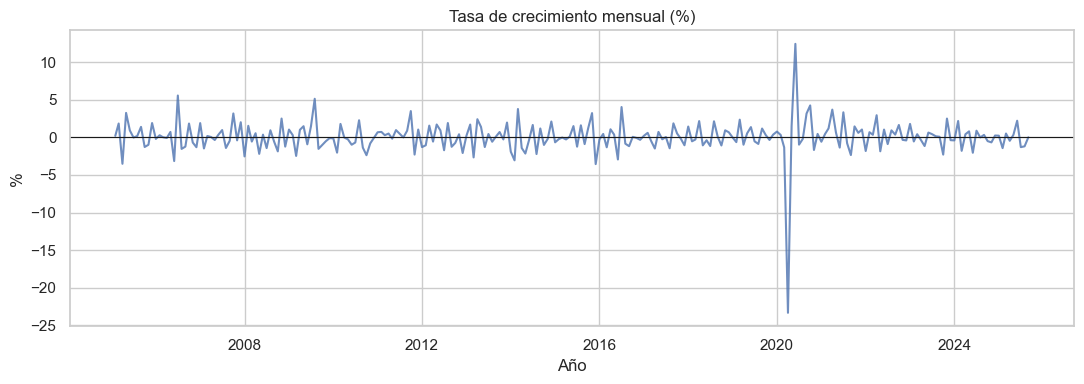

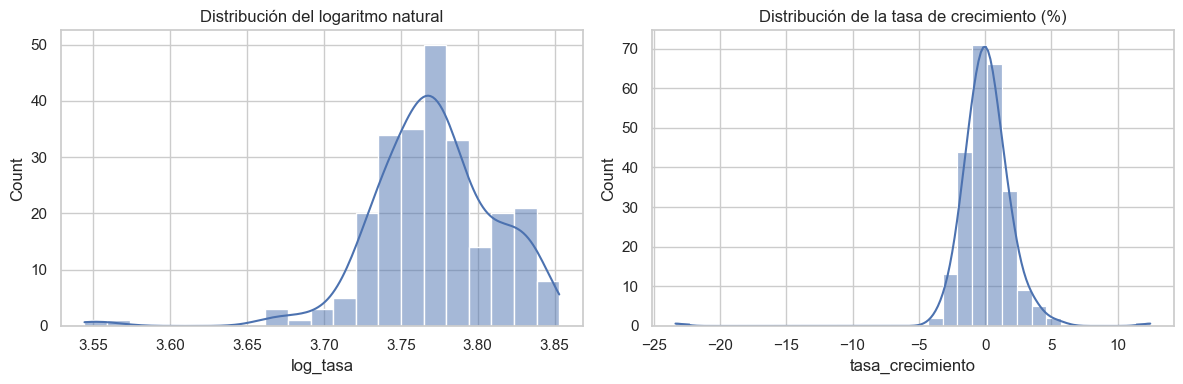


(Sección 2) Estadísticos y exploración

Periodo analizado: 2005-01 – 2025-09  |  Observaciones: 249
Media: 43.47 %, Desv.Est.: 1.75 pp, Min: 34.62 %, Mediana: 43.37 %, Max: 47.14 %
Asimetría (skew): -0.819   |   Curtosis (Fisher): 3.619
Posibles outliers (IQR): 4 observación(es) (ver meses listados abajo).


Meses marcado(s) como posible(s) outlier por IQR:
Fecha
2020-04-01    34.616667
2020-05-01    35.132391
2020-07-01    39.125171
2020-08-01    39.044937


In [12]:

sns.set(style="whitegrid")

#  Carpeta de salida para figuras
outdir = Path("figs")
outdir.mkdir(exist_ok=True)

# Estadísticos descriptivos y forma de la distribución
serie = df['Tasa_participacion'].dropna().copy()
count = serie.shape[0]
mean  = serie.mean()
std   = serie.std()
q1, q2, q3 = serie.quantile([0.25, 0.50, 0.75])
vmin, vmax = serie.min(), serie.max()

# Asimetría y curtosis (Fisher: normal=0)
try:
    from scipy.stats import skew, kurtosis
    skewness = float(skew(serie, nan_policy='omit'))
    kurt_f   = float(kurtosis(serie, nan_policy='omit'))  # Fisher
except Exception:
    skewness = float(serie.skew())       # Pearson
    kurt_f   = float(serie.kurt() - 3)   # aproximación a Fisher

# Detección de posibles outliers por IQR
iqr = q3 - q1
low_fence  = q1 - 1.5 * iqr
high_fence = q3 + 1.5 * iqr
outliers = serie[(serie < low_fence) | (serie > high_fence)]
n_out = outliers.shape[0]

# Visualizaciones de la serie
# 1 Boxplot
plt.figure(figsize=(8,3.5))
plt.boxplot(serie.values, vert=False, whis=1.5)
plt.title('Boxplot - Tasa de participación (mujeres)')
plt.xlabel('% de población femenina (15+)')
plt.tight_layout()
plt.savefig(outdir / "fig03_boxplot.png", dpi=180)
plt.show()

# 2 Histograma (con densidad)
plt.figure(figsize=(8,4.5))
plt.hist(serie.values, bins=20, density=True, alpha=0.65)
plt.title('Distribución de la tasa de participación femenina')
plt.xlabel('% de población femenina (15+)')
plt.ylabel('Densidad')
plt.tight_layout()
plt.savefig(outdir / "fig04_histograma.png", dpi=180)
plt.show()

# 3 Desviación estándar en el tiempo
roll_w = 12
roll_std = serie.rolling(roll_w, min_periods=6).std()

plt.figure(figsize=(10,4))
plt.plot(roll_std, label=f'Desv. estándar (ventana {roll_w}m)')
plt.title('Variabilidad temporal: desviación estándar en el tiempo (12m)')
plt.xlabel('Año'); plt.ylabel('pp')
plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig(outdir / "fig04b_rolling_std.png", dpi=180)
plt.show()

# Transformaciones
# 1 Logaritmo (no imprescindible en porcentajes)
df['log_tasa'] = np.log(df['Tasa_participacion'])

# 2 Diferencia en puntos porcentuales (cambio absoluto mensual)
df['diff_pp'] = df['Tasa_participacion'].diff(1)

# 3 Tasa de crecimiento mensual (%) (cambio relativo)
df['crec_%']  = df['Tasa_participacion'].pct_change(1) * 100
df['tasa_crecimiento'] = df['crec_%']  # alias para gráficos

# 4 Visualización de transformaciones (series en el tiempo)
plt.figure(figsize=(11,4))
plt.plot(df['diff_pp'], alpha=0.8)
plt.axhline(0, color='k', linewidth=0.8)
plt.title('Diferencia mensual (puntos porcentuales)')
plt.xlabel('Año'); plt.ylabel('pp')
plt.grid(True)
plt.tight_layout()
plt.savefig(outdir / "fig05a_diff_pp.png", dpi=180)
plt.show()

plt.figure(figsize=(11,4))
plt.plot(df['crec_%'], alpha=0.8)
plt.axhline(0, color='k', linewidth=0.8)
plt.title('Tasa de crecimiento mensual (%)')
plt.xlabel('Año'); plt.ylabel('%')
plt.grid(True)
plt.tight_layout()
plt.savefig(outdir / "fig05b_crec_pct.png", dpi=180)
plt.show()

# 5 Visualización de transformaciones (distribuciones)
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(df['log_tasa'].dropna(), kde=True, ax=ax[0])
ax[0].set_title('Distribución del logaritmo natural')
sns.histplot(df['tasa_crecimiento'].dropna(), kde=True, ax=ax[1])
ax[1].set_title('Distribución de la tasa de crecimiento (%)')
plt.tight_layout()
plt.savefig(outdir / "fig05c_log_hist.png", dpi=180)
plt.savefig(outdir / "fig05d_growth_hist.png", dpi=180)
plt.show()

#  Resumen 
ini, fin = serie.index.min(), serie.index.max()
txt = f"""
(Sección 2) Estadísticos y exploración

Periodo analizado: {ini.strftime('%Y-%m')} – {fin.strftime('%Y-%m')}  |  Observaciones: {count}
Media: {mean:.2f} %, Desv.Est.: {std:.2f} pp, Min: {vmin:.2f} %, Mediana: {q2:.2f} %, Max: {vmax:.2f} %
Asimetría (skew): {skewness:.3f}   |   Curtosis (Fisher): {kurt_f:.3f}
Posibles outliers (IQR): {n_out} observación(es){' (ver meses listados abajo)' if n_out>0 else ''}.

"""
print(txt)

if n_out > 0:
    print("Meses marcado(s) como posible(s) outlier por IQR:")
    print(outliers.sort_index().to_string())


# Verificación de estacionariedad

Prueba Dickey-Fuller Aumentada (ADF) - Serie en niveles
ADF Statistic: -3.1322314769472266
p-value: 0.02425805585029728
# Lags Used: 2
# Observations: 246
Critical Value 1%: -3.457215237265747
Critical Value 5%: -2.873361841566324
Critical Value 10%: -2.5730700760129555

Conclusión:  Rechazar H0 (serie estacionaria)


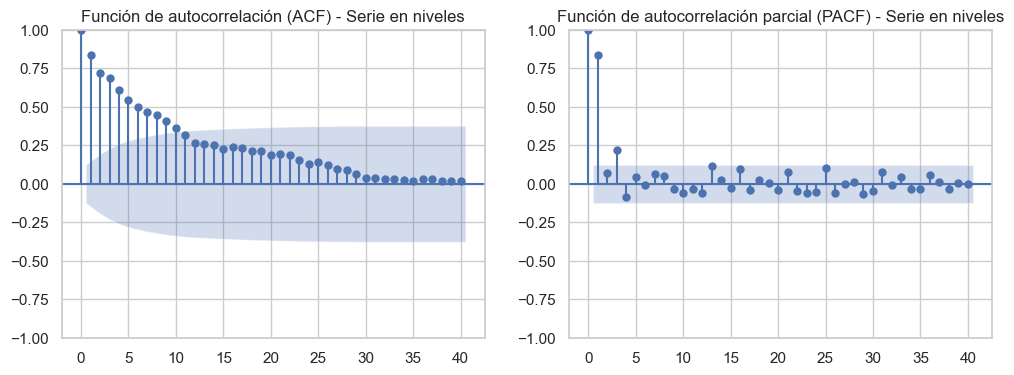


Prueba Dickey-Fuller Aumentada (ADF) - Primera diferencia
ADF Statistic: -15.902705355748816
p-value: 8.293961936443366e-29
# Lags Used: 1
# Observations: 246
Critical Value 1%: -3.457215237265747
Critical Value 5%: -2.873361841566324
Critical Value 10%: -2.5730700760129555

Conclusión:  Rechazar H0 (serie estacionaria)


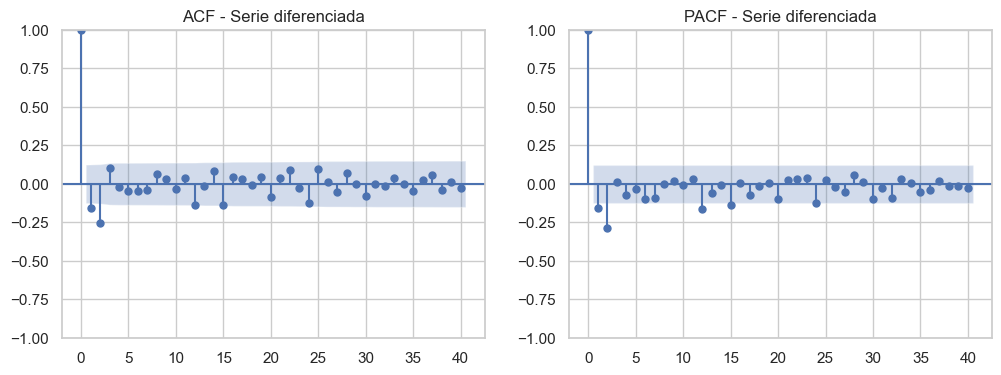

In [13]:

# 1) Prueba ADF en la serie original
print("Prueba Dickey-Fuller Aumentada (ADF) - Serie en niveles")
result = adfuller(df['Tasa_participacion'].dropna(), autolag='AIC')
labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations']
for val, label in zip(result[:4], labels):
    print(f"{label}: {val}")
for key, val in result[4].items():
    print(f"Critical Value {key}: {val}")
print("\nConclusión: ", "Rechazar H0 (serie estacionaria)" if result[1]<0.05 else "No rechazar H0 (serie no estacionaria)")

#  2) ACF y PACF de la serie original
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(df['Tasa_participacion'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['Tasa_participacion'].dropna(), lags=40, ax=axes[1])
axes[0].set_title('Función de autocorrelación (ACF) - Serie en niveles')
axes[1].set_title('Función de autocorrelación parcial (PACF) - Serie en niveles')
plt.show()

# 3) Prueba ADF sobre la serie diferenciada
df['diff_1'] = df['Tasa_participacion'].diff()
print("\nPrueba Dickey-Fuller Aumentada (ADF) - Primera diferencia")
result_diff = adfuller(df['diff_1'].dropna(), autolag='AIC')
for val, label in zip(result_diff[:4], labels):
    print(f"{label}: {val}")
for key, val in result_diff[4].items():
    print(f"Critical Value {key}: {val}")
print("\nConclusión: ", "Rechazar H0 (serie estacionaria)" if result_diff[1]<0.05 else "No rechazar H0 (serie no estacionaria)")

#  4) ACF y PACF de la serie diferenciada
fig, axes = plt.subplots(1,2, figsize=(12,4))
plot_acf(df['diff_1'].dropna(), lags=40, ax=axes[0])
plot_pacf(df['diff_1'].dropna(), lags=40, ax=axes[1])
axes[0].set_title('ACF - Serie diferenciada')
axes[1].set_title('PACF - Serie diferenciada')
plt.show()


# PARTE 4: Diagnóstico con FAC y FACP

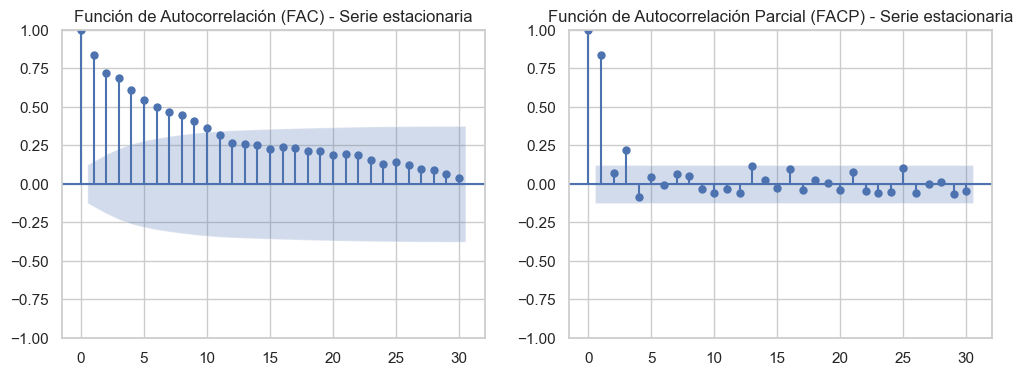

Primeros coeficientes de la FAC:
Lag 0: 1.000
Lag 1: 0.836
Lag 2: 0.720
Lag 3: 0.684
Lag 4: 0.608
Lag 5: 0.546
Lag 6: 0.500
Lag 7: 0.468
Lag 8: 0.449
Lag 9: 0.411
Lag 10: 0.360

Primeros coeficientes de la FACP:
Lag 0: 1.000
Lag 1: 0.839
Lag 2: 0.072
Lag 3: 0.227
Lag 4: -0.086
Lag 5: 0.045
Lag 6: -0.011
Lag 7: 0.070
Lag 8: 0.052
Lag 9: -0.033
Lag 10: -0.062


In [14]:


# Serie estacionaria (original)
serie = df['Tasa_participacion'].dropna()

# 1) Calcular y graficar FAC y FACP
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(serie, lags=30, ax=axes[0])
plot_pacf(serie, lags=30, ax=axes[1])
axes[0].set_title('Función de Autocorrelación (FAC) - Serie estacionaria')
axes[1].set_title('Función de Autocorrelación Parcial (FACP) - Serie estacionaria')
plt.show()

# 2) Inspeccionar los primeros coeficientes numéricamente
from statsmodels.tsa.stattools import acf, pacf

acf_vals = acf(serie, nlags=10)
pacf_vals = pacf(serie, nlags=10)

print("Primeros coeficientes de la FAC:")
for i, v in enumerate(acf_vals):
    print(f"Lag {i}: {v:.3f}")

print("\nPrimeros coeficientes de la FACP:")
for i, v in enumerate(pacf_vals):
    print(f"Lag {i}: {v:.3f}")


# Estimación del modelo

## AR(1)

In [15]:
# 1) Definir la serie estacionaria (ya usada antes)
serie = df['Tasa_participacion'].dropna()


In [16]:

#  Ajustar el modelo AR(1) ~ ARIMA(1,0,0)
model_ar1 = ARIMA(serie, order=(1, 0, 0)).fit()

print("=== Modelo AR(1) estimado sobre la serie en niveles ===")
print(model_ar1.summary())

#  Extraer parámetros clave
phi1 = model_ar1.params.get('ar.L1', float('nan'))
const = model_ar1.params.get('const', float('nan'))

print("\nParámetros principales:")
print(f"Constante: {const:.4f}")
print(f"Phi_1 (AR1): {phi1:.4f}")
print(f"AIC: {model_ar1.aic:.2f}")
print(f"BIC: {model_ar1.bic:.2f}")


=== Modelo AR(1) estimado sobre la serie en niveles ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -337.648
Date:                Wed, 19 Nov 2025   AIC                            681.296
Time:                        22:57:58   BIC                            691.848
Sample:                    01-01-2005   HQIC                           685.543
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4494      0.506     85.895      0.000      42.458      44.441
ar.L1          0.8480      0.031     27.307      0.000       0.787       0.

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [17]:

#  Residuos del modelo
resid = model_ar1.resid

#  Prueba de Ljung–Box para los residuos
lb = acorr_ljungbox(resid, lags=[10], return_df=True)

print("\n=== Prueba de Ljung–Box (residuos AR(1)) ===")
print(lb)

pval = lb['lb_pvalue'].iloc[0]
if pval > 0.05:
    print("\nConclusión: No se rechaza H0 de 'no autocorrelación' en los residuos (ruido blanco).")
else:
    print("\nConclusión: Se rechaza H0; los residuos muestran autocorrelación (modelo AR(1) puede ser insuficiente).")



=== Prueba de Ljung–Box (residuos AR(1)) ===
      lb_stat  lb_pvalue
10  19.270314   0.036961

Conclusión: Se rechaza H0; los residuos muestran autocorrelación (modelo AR(1) puede ser insuficiente).


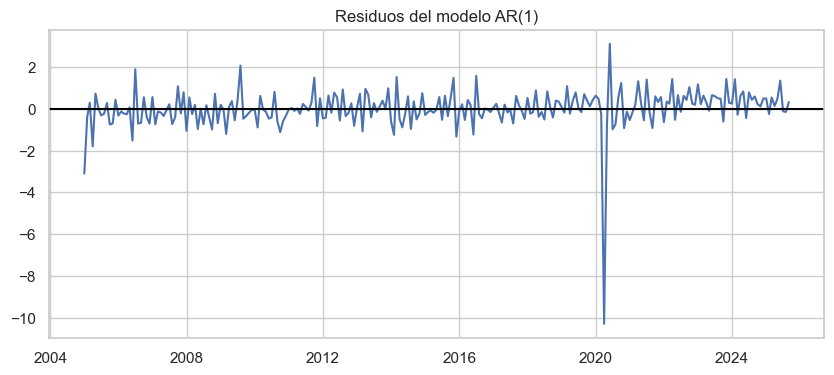

In [18]:
plt.figure(figsize=(10,4))
plt.plot(serie.index, resid)
plt.axhline(0, color='black')
plt.title("Residuos del modelo AR(1)")
plt.show()


<Figure size 800x400 with 0 Axes>

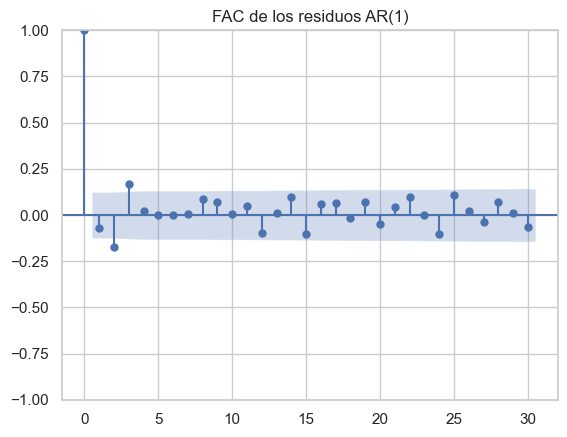

In [19]:
plt.figure(figsize=(8,4))
plot_acf(resid, lags=30)
plt.title("FAC de los residuos AR(1)")
plt.show()


<Figure size 800x400 with 0 Axes>

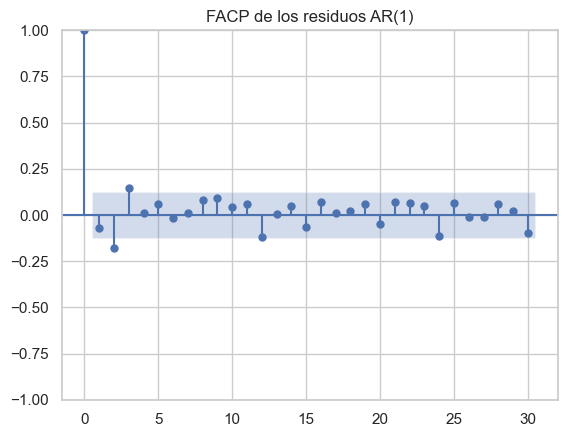

In [20]:

plt.figure(figsize=(8,4))
plot_pacf(resid, lags=30)
plt.title("FACP de los residuos AR(1)")
plt.show()

## MA(1)

In [21]:

model_ma1 = ARIMA(serie, order=(0, 0, 1)).fit()

print("=== Modelo MA(1) estimado sobre la serie en niveles ===")
print(model_ma1.summary())

#  Extraer parámetros clave
theta1 = model_ma1.params.get('ma.L1', float('nan'))
const = model_ma1.params.get('const', float('nan'))

print("\nParámetros principales:")
print(f"Constante: {const:.4f}")
print(f"Theta_1 (MA1): {theta1:.4f}")
print(f"AIC: {model_ma1.aic:.2f}")
print(f"BIC: {model_ma1.bic:.2f}")


=== Modelo MA(1) estimado sobre la serie en niveles ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -399.829
Date:                Wed, 19 Nov 2025   AIC                            805.658
Time:                        22:57:59   BIC                            816.211
Sample:                    01-01-2005   HQIC                           809.906
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4728      0.151    288.085      0.000      43.177      43.769
ma.L1          0.7455      0.039     19.339      0.000       0.670       0.

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [22]:

# 4) Residuos del modelo
resid = model_ma1.resid

# 4.3) Prueba de Ljung–Box para los residuos
lb = acorr_ljungbox(resid, lags=[10], return_df=True)

print("\n=== Prueba de Ljung–Box (residuos MA(1)) ===")
print(lb)

pval = lb['lb_pvalue'].iloc[0]
if pval > 0.05:
    print("\nConclusión: No se rechaza H0 de 'no autocorrelación' en los residuos (ruido blanco).")
else:
    print("\nConclusión: Se rechaza H0; los residuos muestran autocorrelación (modelo MA(1) puede ser insuficiente).")



=== Prueba de Ljung–Box (residuos MA(1)) ===
       lb_stat     lb_pvalue
10  373.149588  4.832342e-74

Conclusión: Se rechaza H0; los residuos muestran autocorrelación (modelo MA(1) puede ser insuficiente).


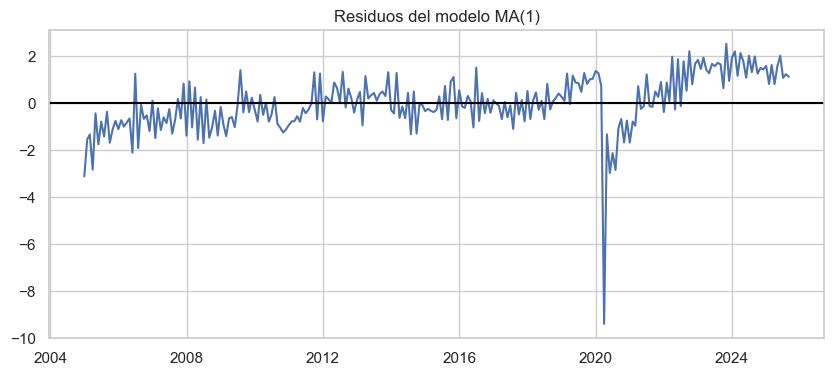

In [23]:
plt.figure(figsize=(10,4))
plt.plot(serie.index, resid)
plt.axhline(0, color='black')
plt.title("Residuos del modelo MA(1)")
plt.show()


<Figure size 800x400 with 0 Axes>

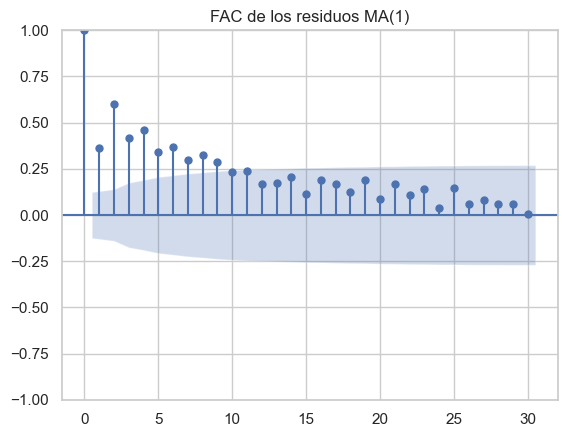

In [24]:
plt.figure(figsize=(8,4))
plot_acf(resid, lags=30)
plt.title("FAC de los residuos MA(1)")
plt.show()


<Figure size 800x400 with 0 Axes>

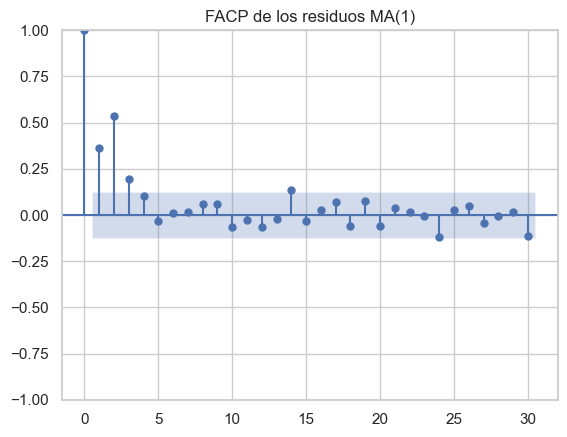

In [25]:
plt.figure(figsize=(8,4))
plot_pacf(resid, lags=30)
plt.title("FACP de los residuos MA(1)")
plt.show()


## ARMA(1,1)

In [26]:


model_arma11 = ARIMA(serie, order=(1, 0, 1)).fit()

print("=== Modelo ARMA(1,1) estimado sobre la serie en niveles ===")
print(model_arma11.summary())

# 3) Extraer parámetros clave
phi1   = model_arma11.params.get('ar.L1', float('nan'))
theta1 = model_arma11.params.get('ma.L1', float('nan'))
const  = model_arma11.params.get('const', float('nan'))

print("\nParámetros principales:")
print(f"Constante: {const:.4f}")
print(f"Phi_1 (AR1): {phi1:.4f}")
print(f"Theta_1 (MA1): {theta1:.4f}")
print(f"AIC: {model_arma11.aic:.2f}")
print(f"BIC: {model_arma11.bic:.2f}")


=== Modelo ARMA(1,1) estimado sobre la serie en niveles ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -335.943
Date:                Wed, 19 Nov 2025   AIC                            679.885
Time:                        22:57:59   BIC                            693.955
Sample:                    01-01-2005   HQIC                           685.549
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4391      0.620     70.053      0.000      42.224      44.654
ar.L1          0.8998      0.039     23.089      0.000       0.823     

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [27]:

# 4) Residuos del modelo
resid = model_arma11.resid

# 4.3) Prueba de Ljung–Box para los residuos
lb = acorr_ljungbox(resid, lags=[10], return_df=True)

print("\n=== Prueba de Ljung–Box (residuos ARMA(1,1)) ===")
print(lb)

pval = lb['lb_pvalue'].iloc[0]
if pval > 0.05:
    print("\nConclusión: No se rechaza H0 de 'no autocorrelación' en los residuos (ruido blanco).")
else:
    print("\nConclusión: Se rechaza H0; los residuos muestran autocorrelación.")



=== Prueba de Ljung–Box (residuos ARMA(1,1)) ===
      lb_stat  lb_pvalue
10  15.931045   0.101623

Conclusión: No se rechaza H0 de 'no autocorrelación' en los residuos (ruido blanco).


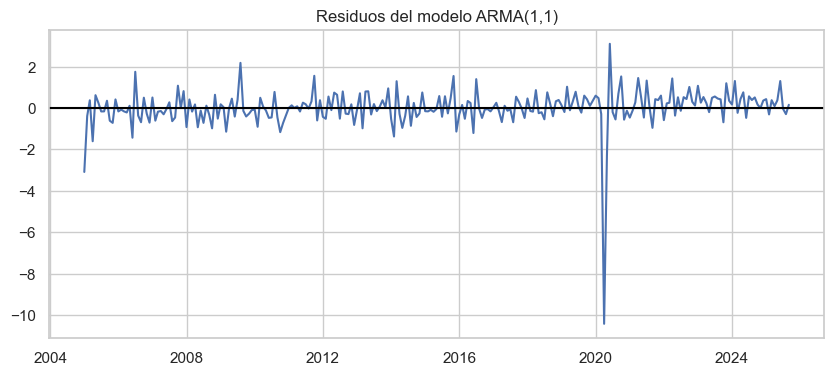

In [28]:
plt.figure(figsize=(10,4))
plt.plot(serie.index, resid)
plt.axhline(0, color='black')
plt.title("Residuos del modelo ARMA(1,1)")
plt.show()


<Figure size 800x400 with 0 Axes>

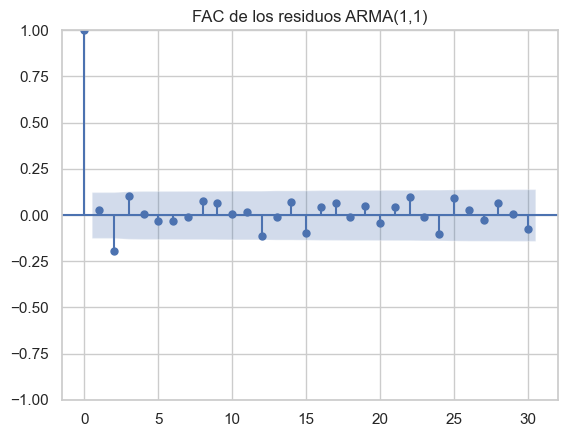

In [29]:
plt.figure(figsize=(8,4))
plot_acf(resid, lags=30)
plt.title("FAC de los residuos ARMA(1,1)")
plt.show()


<Figure size 800x400 with 0 Axes>

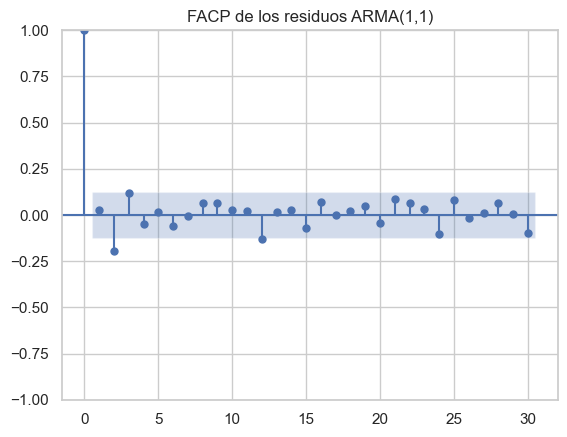

In [30]:
plt.figure(figsize=(8,4))
plot_pacf(resid, lags=30)
plt.title("FACP de los residuos ARMA(1,1)")
plt.show()


Comparación de AIC

In [31]:
import pandas as pd

modelos = {
    "AR(1)": model_ar1,
    "MA(1)": model_ma1,
    "ARMA(1,1)": model_arma11,
}

rows_ic = []
for nombre, mod in modelos.items():
    rows_ic.append({
        "Modelo": nombre,
        "AIC": mod.aic,
        "BIC": mod.bic,
    })

df_ic = pd.DataFrame(rows_ic)
df_ic


,Modelo,AIC,BIC
0,AR(1),681.295796,691.848155
1,MA(1),805.658408,816.210766
2,"ARMA(1,1)",679.885451,693.955262


In [32]:
rows_sig = []

for nombre, mod in modelos.items():
    params = mod.params
    pvals = mod.pvalues

    for par in params.index:
        # si no quieres sigma2 en la tabla, lo filtramos
        if par.lower().startswith("sigma"):
            continue

        rows_sig.append({
            "Modelo": nombre,
            "Parametro": par,
            "Estimacion": params[par],
            "p_value": pvals[par],
            "Significativo_5pct": pvals[par] < 0.05
        })

df_sig = pd.DataFrame(rows_sig)
df_sig


,Modelo,Parametro,Estimacion,p_value,Significativo_5pct
0,AR(1),const,43.449419,0.000000e+00,True
1,AR(1),ar.L1,0.848004,3.495771e-164,True
2,MA(1),const,43.472801,0.000000e+00,True
3,MA(1),ma.L1,0.745530,2.542017e-83,True
4,"ARMA(1,1)",const,43.439123,0.000000e+00,True
5,"ARMA(1,1)",ar.L1,0.899776,5.984189e-118,True
6,"ARMA(1,1)",ma.L1,-0.187464,3.701498e-04,True


#  Selección modelo final


c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


=== Modelo final ARMA(1,1) estimado sobre la serie de tasa de participación femenina ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -335.943
Date:                Wed, 19 Nov 2025   AIC                            679.885
Time:                        22:58:00   BIC                            693.955
Sample:                    01-01-2005   HQIC                           685.549
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4391      0.620     70.053      0.000      42.224      44.654
ar.L1          0.8998      0.039     23.08

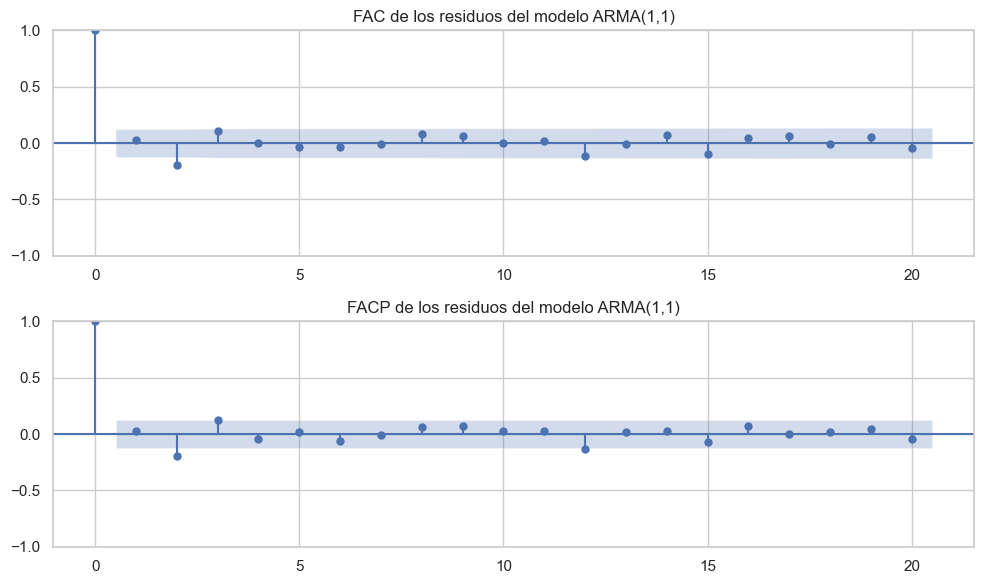

In [33]:


# Modelo final ARMA(1,1) sobre la serie en niveles
order_final = (1, 0, 1)
model_final = ARIMA(serie, order=order_final).fit()

print("=== Modelo final ARMA(1,1) estimado sobre la serie de tasa de participación femenina ===")
print(model_final.summary())
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

resid_final = model_final.resid

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(resid_final, ax=ax[0], lags=20)
ax[0].set_title("FAC de los residuos del modelo ARMA(1,1)")

plot_pacf(resid_final, ax=ax[1], lags=20)
ax[1].set_title("FACP de los residuos del modelo ARMA(1,1)")

plt.tight_layout()
plt.show()


In [34]:
from statsmodels.tsa.arima.model import ARIMA

# --- Modelo final: ARMA(1,1) sobre la serie estacionaria en niveles ---
order_final = (1, 0, 1)   # (p, d, q)

model_final = ARIMA(serie, order=order_final).fit()

print("=== Modelo final ARMA(1,1) estimado sobre la serie de tasa de participación femenina ===")
print(model_final.summary())


=== Modelo final ARMA(1,1) estimado sobre la serie de tasa de participación femenina ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -335.943
Date:                Wed, 19 Nov 2025   AIC                            679.885
Time:                        22:58:00   BIC                            693.955
Sample:                    01-01-2005   HQIC                           685.549
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4391      0.620     70.053      0.000      42.224      44.654
ar.L1          0.8998      0.039     23.08

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


# Pronóstico a 10 periodos con el ARMA(1,1)

In [35]:

# model_final
forecast_10 = model_final.get_forecast(steps=10)

# Extraer tabla con pronósticos
pred_mean = forecast_10.predicted_mean
pred_ci = forecast_10.conf_int(alpha=0.05)
pred_se = forecast_10.se_mean

# Construcción del DataFrame tipo Cuadro 6.3
df_forecast_10 = pd.DataFrame({
    "Lead": range(1, 11),
    "Pronóstico": pred_mean.values,
    "Error estándar": pred_se.values,
    "Límite inferior 95%": pred_ci.iloc[:, 0].values,
    "Límite superior 95%": pred_ci.iloc[:, 1].values
})

df_forecast_10.index = pred_mean.index  # fechas de los pronósticos

print("\n=== Tabla de Pronóstico a 10 periodos  ===")
print(df_forecast_10)



=== Tabla de Pronóstico a 10 periodos  ===
            Lead  Pronóstico  Error estándar  Límite inferior 95%  \
2025-10-01     1   45.283087        0.930122            43.460083   
2025-11-01     2   45.098278        1.141964            42.860070   
2025-12-01     3   44.931992        1.288200            42.407167   
2026-01-01     4   44.782371        1.395410            42.047416   
2026-02-01     5   44.647745        1.476517            41.753826   
2026-03-01     6   44.526613        1.539052            41.510126   
2026-04-01     7   44.417620        1.587878            41.305437   
2026-05-01     8   44.319552        1.626333            41.131997   
2026-06-01     9   44.231312        1.656813            40.984018   
2026-07-01    10   44.151916        1.681085            40.857050   

            Límite superior 95%  
2025-10-01            47.106092  
2025-11-01            47.336486  
2025-12-01            47.456816  
2026-01-01            47.517325  
2026-02-01            47.5

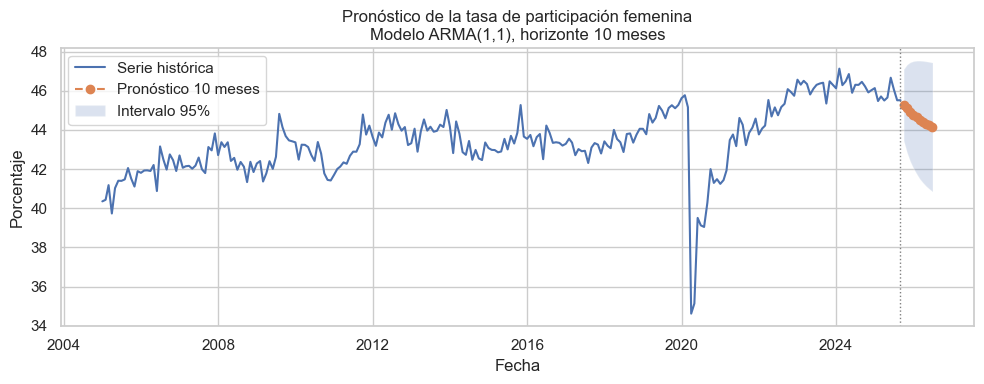

In [36]:
plt.figure(figsize=(10,4))

# Serie histórica
plt.plot(serie, label="Serie histórica")

# Pronóstico puntual
plt.plot(pred_mean.index, pred_mean, linestyle="--", marker="o",
         label="Pronóstico 10 meses")

# Banda de intervalo de predicción 95%
plt.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    alpha=0.2,
    label="Intervalo 95%"
)

# Línea vertical en el último dato observado
plt.axvline(serie.index[-1], color="gray", linestyle=":", linewidth=1)

plt.title("Pronóstico de la tasa de participación femenina\nModelo ARMA(1,1), horizonte 10 meses")
plt.xlabel("Fecha")
plt.ylabel("Porcentaje")
plt.legend()
plt.tight_layout()
plt.show()


In [37]:

# Definimos un conjunto pequeño de modelos candidatos "automáticos"
candidate_orders = [
    (1, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
    (2, 0, 0),
    (0, 0, 2),
    (2, 0, 1),
    (1, 0, 2)
]

results_auto = []

for order in candidate_orders:
    try:
        model = ARIMA(serie, order=order).fit()
        results_auto.append({
            "order": order,
            "aic": model.aic,
            "bic": model.bic,
            "model": model
        })
    except Exception as e:
        print(f"Falló el modelo {order}: {e}")

# Pasamos a DataFrame para verlos ordenados por AIC
df_auto_search = pd.DataFrame([
    {"order": r["order"], "AIC": r["aic"], "BIC": r["bic"]}
    for r in results_auto
]).sort_values("AIC").reset_index(drop=True)

print("=== Modelos probados (búsqueda automática) ===")
print(df_auto_search)


c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be use

=== Modelos probados (búsqueda automática) ===
       order         AIC         BIC
0  (1, 0, 2)  670.936101  688.523366
1  (1, 0, 1)  679.885451  693.955262
2  (1, 0, 0)  681.295796  691.848155
3  (2, 0, 0)  681.620589  695.690400
4  (2, 0, 1)  682.231852  699.819117
5  (0, 0, 2)  764.521597  778.591409
6  (0, 0, 1)  805.658408  816.210766


In [38]:
# Tomamos el modelo con menor AIC
best_auto = min(results_auto, key=lambda r: r["aic"])
order_auto = best_auto["order"]
model_auto = best_auto["model"]

print(f"\n=== Modelo automático elegido (por AIC) === ARIMA{order_auto}")
print(model_auto.summary())

# Pronóstico a 10 periodos
forecast_auto_10 = model_auto.get_forecast(steps=10)
pred_auto_mean = forecast_auto_10.predicted_mean

# DataFrame alineado con fechas de pronóstico manual
df_auto_10 = pd.DataFrame({
    "Pronóstico_auto": pred_auto_mean.values
}, index=df_forecast_10.index)

print("\n=== Pronóstico automático a 10 periodos ===")
print(df_auto_10)



=== Modelo automático elegido (por AIC) === ARIMA(1, 0, 2)
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  249
Model:                 ARIMA(1, 0, 2)   Log Likelihood                -330.468
Date:                Wed, 19 Nov 2025   AIC                            670.936
Time:                        22:58:01   BIC                            688.523
Sample:                    01-01-2005   HQIC                           678.015
                         - 09-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4320      0.755     57.543      0.000      41.953      44.911
ar.L1          0.9448      0.039     24.423      0.000       0.869     

In [39]:
df_comp = pd.DataFrame({
    "Pronóstico_manual_ARMA(1,1)": df_forecast_10["Pronóstico"],
    f"Pronóstico_auto_ARIMA{order_auto}": df_auto_10["Pronóstico_auto"]
})

print("\n=== Comparación de pronósticos: modelo manual vs 'automático' ===")
print(df_comp)



=== Comparación de pronósticos: modelo manual vs 'automático' ===
            Pronóstico_manual_ARMA(1,1)  Pronóstico_auto_ARIMA(1, 0, 2)
2025-10-01                    45.283087                       45.432489
2025-11-01                    45.098278                       45.307927
2025-12-01                    44.931992                       45.204341
2026-01-01                    44.782371                       45.106475
2026-02-01                    44.647745                       45.014013
2026-03-01                    44.526613                       44.926657
2026-04-01                    44.417620                       44.844125
2026-05-01                    44.319552                       44.766150
2026-06-01                    44.231312                       44.692480
2026-07-01                    44.151916                       44.622879


# Serie actualizada

In [40]:

# 1) Nuevo dato observado = pronóstico lead 1
nuevo_valor = df_forecast_10["Pronóstico"].iloc[0]
print("Nuevo dato observado (simulado):", nuevo_valor)

# 2) Fecha inmediatamente posterior al último dato histórico
ultima_fecha = serie.index[-1]
nueva_fecha = ultima_fecha + pd.DateOffset(months=1)

print("Última fecha histórica:", ultima_fecha)
print("Nueva fecha simulada:", nueva_fecha)

# 3) Crear serie actualizada
serie_actualizada = serie.copy()
serie_actualizada.loc[nueva_fecha] = nuevo_valor
serie_actualizada = serie_actualizada.sort_index()

print("\nÚltimas observaciones de la serie actualizada:")
print(serie_actualizada.tail())


Nuevo dato observado (simulado): 45.2830873262225
Última fecha histórica: 2025-09-01 00:00:00
Nueva fecha simulada: 2025-10-01 00:00:00

Últimas observaciones de la serie actualizada:
Fecha
2025-06-01    46.670945
2025-07-01    46.065398
2025-08-01    45.516931
2025-09-01    45.521386
2025-10-01    45.283087
Name: Tasa_participacion, dtype: float64


In [41]:

order_final = (1, 0, 1)

model_update = ARIMA(serie_actualizada, order=order_final).fit()

print("=== Modelo ARMA(1,1) reestimado con la serie actualizada ===")
print(model_update.summary())


=== Modelo ARMA(1,1) reestimado con la serie actualizada ===
                               SARIMAX Results                                
Dep. Variable:     Tasa_participacion   No. Observations:                  250
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -336.788
Date:                Wed, 19 Nov 2025   AIC                            681.576
Time:                        22:58:01   BIC                            695.662
Sample:                    01-01-2005   HQIC                           687.246
                         - 10-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.4391      0.618     70.320      0.000      42.228      44.650
ar.L1          0.8998      0.039     23.185      0.000       0.824    

c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\narro\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [42]:
# Pronóstico actualizado a 9 periodos con el modelo reestimado
forecast_9 = model_update.get_forecast(steps=9)

pred_mean_9 = forecast_9.predicted_mean
pred_ci_9   = forecast_9.conf_int(alpha=0.05)
pred_se_9   = forecast_9.se_mean

# Construcción de la tabla tipo Cuadro 6.4
df_forecast_9 = pd.DataFrame({
    "Lead": range(1, 10),
    "Pronóstico actualizado": pred_mean_9.values,
    "Error estándar": pred_se_9.values,
    "Límite inferior 95%": pred_ci_9.iloc[:, 0].values,
    "Límite superior 95%": pred_ci_9.iloc[:, 1].values
}, index=pred_mean_9.index)

print("\n=== Tabla de Pronóstico ACTUALIZADO a 9 periodos ===")
print(df_forecast_9)



=== Tabla de Pronóstico ACTUALIZADO a 9 periodos ===
            Lead  Pronóstico actualizado  Error estándar  Límite inferior 95%  \
2025-11-01     1               45.098320        0.928257            43.278969   
2025-12-01     2               44.932059        1.139676            42.698335   
2026-01-01     3               44.782459        1.285625            42.262680   
2026-02-01     4               44.647849        1.392629            41.918347   
2026-03-01     5               44.526728        1.473581            41.638562   
2026-04-01     6               44.417745        1.536000            41.407240   
2026-05-01     7               44.319682        1.584736            41.213656   
2026-06-01     8               44.231446        1.623123            41.050183   
2026-07-01     9               44.152051        1.653549            40.911155   

            Límite superior 95%  
2025-11-01            46.917671  
2025-12-01            47.165783  
2026-01-01            47.302237  

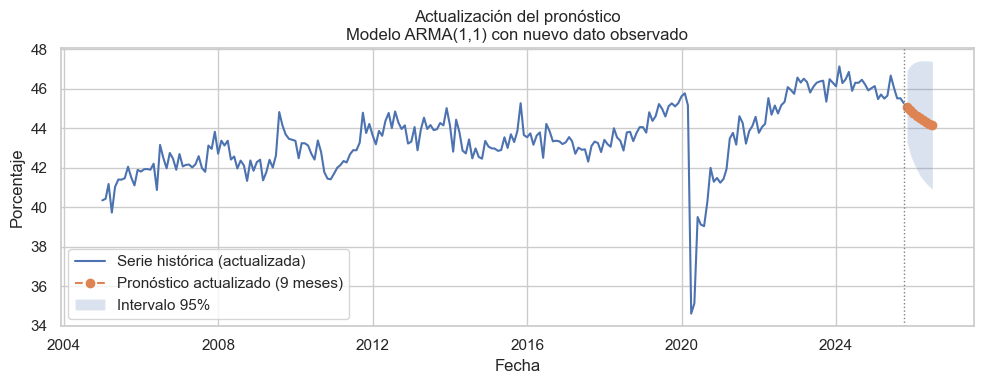

In [43]:


plt.figure(figsize=(10,4))

# Serie histórica actualizada (incluye el nuevo dato de 2025-10-01)
plt.plot(serie_actualizada, label="Serie histórica (actualizada)")

# Pronóstico actualizado
plt.plot(pred_mean_9.index, pred_mean_9, linestyle="--", marker="o",
         label="Pronóstico actualizado (9 meses)")

# Intervalo 95%
plt.fill_between(
    pred_ci_9.index,
    pred_ci_9.iloc[:, 0],
    pred_ci_9.iloc[:, 1],
    alpha=0.2,
    label="Intervalo 95%"
)

# Línea vertical en el nuevo origen del pronóstico
plt.axvline(serie_actualizada.index[-1], color="gray", linestyle=":", linewidth=1)

plt.title("Actualización del pronóstico\nModelo ARMA(1,1) con nuevo dato observado")
plt.xlabel("Fecha")
plt.ylabel("Porcentaje")
plt.legend()
plt.tight_layout()
plt.show()
